In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

# Generate data
data = {
    "patient_id": range(1, n+1),

    # Age: realistic hospital range with some noise
    "age": np.random.randint(18, 90, n),

    # BMI: normal + some extreme values for cleaning
    "bmi": np.round(np.random.normal(27, 6, n), 1),

    # Gender
    "gender": np.random.choice(["Male", "Female"], n),

    # Conditions
    "hypertension": np.random.choice([0, 1], n, p=[0.7, 0.3]),
    "diabetes": np.random.choice([0, 1], n, p=[0.75, 0.25]),
    "heart_disease": np.random.choice([0, 1], n, p=[0.85, 0.15]),

    # Health metrics
    "avg_glucose_level": np.round(np.random.normal(120, 40, n), 1),

    # Lifestyle
    "smoking_status": np.random.choice(
        ["never", "former", "smokes"], n, p=[0.6, 0.25, 0.15]
    ),
}

df = pd.DataFrame(data)

# --- Create realistic target (IMPORTANT) ---
# Higher risk if older + diseases + high BMI + high glucose
risk_score = (
    (df["age"] > 60).astype(int) +
    df["hypertension"] +
    df["diabetes"] +
    df["heart_disease"] +
    (df["bmi"] > 30).astype(int) +
    (df["avg_glucose_level"] > 150).astype(int)
)

# Convert to probability
prob = 1 / (1 + np.exp(-risk_score))

df["readmitted"] = np.random.binomial(1, prob)

# --- Introduce REAL-WORLD MESSINESS (VERY IMPORTANT FOR EASY PART) ---
# Missing values
df.loc[np.random.choice(n, 100), "bmi"] = np.nan
df.loc[np.random.choice(n, 50), "smoking_status"] = None

# Invalid values
df.loc[np.random.choice(n, 20), "age"] = -5   # wrong age
df.loc[np.random.choice(n, 20), "bmi"] = 80   # extreme BMI

# Save
df.to_csv("hospital_records.csv", index=False)

print("Dataset created successfully with shape:", df.shape)



Dataset created successfully with shape: (2000, 10)


EASY Sub-step 1: Data Quality Audit

In [2]:
import pandas as pd

df = pd.read_csv('/content/hospital_records.csv')

print(df.shape)
df.head()

(2000, 10)


,patient_id,age,bmi,gender,hypertension,diabetes,heart_disease,avg_glucose_level,smoking_status,readmitted
0,1,69,21.0,Male,0,0,0,88.3,never,0
1,2,32,26.8,Female,1,0,0,154.9,never,1
2,3,89,15.2,Female,0,0,1,90.5,smokes,1
3,4,78,39.4,Female,0,0,0,42.0,former,1
4,5,38,NaN,Male,1,0,0,147.9,former,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         2000 non-null   int64  
 1   age                2000 non-null   int64  
 2   bmi                1904 non-null   float64
 3   gender             2000 non-null   object 
 4   hypertension       2000 non-null   int64  
 5   diabetes           2000 non-null   int64  
 6   heart_disease      2000 non-null   int64  
 7   avg_glucose_level  2000 non-null   float64
 8   smoking_status     1950 non-null   object 
 9   readmitted         2000 non-null   int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 156.4+ KB


,patient_id,age,bmi,hypertension,diabetes,heart_disease,avg_glucose_level,readmitted
count,2000.000000,2000.000000,1904.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000
mean,1000.500000,52.129000,27.457773,0.296500,0.217000,0.152000,118.78490,0.78700
std,577.494589,21.457343,8.031800,0.456828,0.412306,0.359111,39.29228,0.40953
min,1.000000,-5.000000,6.200000,0.000000,0.000000,0.000000,-18.20000,0.00000
25%,500.750000,34.000000,22.800000,0.000000,0.000000,0.000000,92.07500,1.00000
50%,1000.500000,52.000000,27.000000,0.000000,0.000000,0.000000,118.15000,1.00000
75%,1500.250000,71.000000,31.300000,1.000000,0.000000,0.000000,144.65000,1.00000
max,2000.000000,89.000000,80.000000,1.000000,1.000000,1.000000,261.80000,1.00000


In [4]:
df.isnull().sum()

,0
patient_id,0
age,0
bmi,96
gender,0
hypertension,0
diabetes,0
heart_disease,0
avg_glucose_level,0
smoking_status,50
readmitted,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
for col in df.columns:
    print(col, df[col].unique())

patient_id [   1    2    3 ... 1998 1999 2000]
age [69 32 89 78 38 41 20 39 70 19 47 55 81 77 50 75 66 76 59 79 64 68 72 24
 56 35 21 31 26 88 61 25 52 53 67 23 71 80 51 65 57 43 58 46 62 82 18 28
 22 45 29 40 54 44 60 30 49 83 74 87 73 -5 36 85 34 86 33 37 84 48 42 63
 27]
bmi [21.  26.8 15.2 39.4  nan 21.8 13.2 24.3 13.3 28.7 28.2 33.9 20.3 17.4
 24.6 26.5 32.5 35.5 34.3 31.8 23.2 28.  19.9 27.4 27.5 37.3 25.6 28.4
 22.2 34.8 21.1 19.  31.1 22.8 22.3 32.3 30.6 34.9 19.5 24.  21.4 30.9
 23.5 27.2 80.  37.8 31.5 21.9 29.2 30.3 25.7 23.4 19.3 16.6 15.3 30.5
 27.9 24.1 25.  28.3 26.  28.8 28.6 32.  22.1 26.2 31.4 20.8 30.  29.
 26.4 31.9 18.  31.3 40.8 33.5 15.6 37.9 30.7 32.4 23.3 29.9 25.5 26.9
 34.7 24.5 18.6 35.7 18.3 20.4 14.4 16.8 37.1 22.5 34.  23.6 28.1 22.
 40.3 25.2 27.8 22.9 38.2 38.3 36.8 32.7 27.  33.7 23.1 10.4 24.4 21.7
 18.8 20.5 24.9 34.2 15.4 29.1 18.5 20.  23.8 31.6 33.2 25.8 24.8 29.4
 35.3 26.7 24.7  9.8 31.7 21.6 21.5 36.4 27.6 20.2 16.4 31.2 26.3 30.4
 41.5 25.1 23

In [7]:
# Age issues
print(df[df['age'] < 0])

# BMI issues
print(df[df['bmi'] > 60])

# Glucose issues
print(df[df['avg_glucose_level'] < 0])

      patient_id  age   bmi  gender  hypertension  diabetes  heart_disease  \
165          166   -5  28.6    Male             0         0              0   
221          222   -5  30.4  Female             0         0              0   
444          445   -5  29.3    Male             0         0              0   
522          523   -5  33.7  Female             0         0              0   
617          618   -5  31.3    Male             1         0              0   
707          708   -5  25.3    Male             0         1              0   
742          743   -5  17.8  Female             1         1              0   
912          913   -5  34.3  Female             0         0              0   
1008        1009   -5  25.2    Male             0         0              0   
1036        1037   -5  17.6  Female             1         0              0   
1261        1262   -5  22.9  Female             0         0              0   
1348        1349   -5  19.1  Female             0         1     

EASY Sub-step 2: Data Cleaning

In [8]:
# Fill BMI with median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Fill smoking_status with mode
df['smoking_status'].fillna(df['smoking_status'].mode()[0], inplace=True)

/tmp/ipykernel_23267/4275218902.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)
/tmp/ipykernel_23267/4275218902.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [9]:
# Remove negative age
df = df[df['age'] >= 0]

# Cap BMI
df['bmi'] = df['bmi'].clip(10, 50)

In [10]:
# Cap glucose
df['avg_glucose_level'] = df['avg_glucose_level'].clip(50, 300)

In [11]:
# Gender encoding
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# Smoking encoding
df = pd.get_dummies(df, columns=['smoking_status'], drop_first=True)

In [13]:
df.isnull().sum()


,0
patient_id,0
age,0
bmi,0
gender,0
hypertension,0
diabetes,0
heart_disease,0
avg_glucose_level,0
readmitted,0
smoking_status_never,0


In [14]:
df.head()

,patient_id,age,bmi,gender,hypertension,diabetes,heart_disease,avg_glucose_level,readmitted,smoking_status_never,smoking_status_smokes
0,1,69,21.0,0,0,0,0,88.3,0,True,False
1,2,32,26.8,1,1,0,0,154.9,1,True,False
2,3,89,15.2,1,0,0,1,90.5,1,False,True
3,4,78,39.4,1,0,0,0,50.0,1,False,False
4,5,38,27.0,0,1,0,0,147.9,1,False,False


MEDIUM Sub-step 3: Build Neural Network

In [17]:
import numpy as np

# Drop ID column
df_model = df.drop(columns=['patient_id'])

# Convert boolean columns to int for numerical operations
for col in ['smoking_status_never', 'smoking_status_smokes']:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(int)

# Split features and target
X = df_model.drop(columns=['readmitted']).values
y = df_model['readmitted'].values.reshape(-1, 1)

# Normalize features (IMPORTANT)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [18]:
input_size = X_train.shape[1]
hidden_size = 16
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [19]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [20]:
def forward(X):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return A1, A2

In [21]:
def compute_loss(y, y_hat):
    m = y.shape[0]
    loss = - (1/m) * np.sum(
        y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8)
    )
    return loss

In [22]:
def backward(X, y, A1, A2, lr=0.01):
    global W1, b1, W2, b2
    m = X.shape[0]

    dZ2 = A2 - y
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

MEDIUM Sub-step 4: Train + Evaluate

In [27]:
losses = []

for epoch in range(1000):
    A1, A2 = forward(X_train)
    loss = compute_loss(y_train, A2)
    losses.append(loss)

    backward(X_train, y_train, A1, A2, lr=0.01)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.5130
Epoch 100, Loss: 0.5127
Epoch 200, Loss: 0.5124
Epoch 300, Loss: 0.5121
Epoch 400, Loss: 0.5118
Epoch 500, Loss: 0.5115
Epoch 600, Loss: 0.5111
Epoch 700, Loss: 0.5108
Epoch 800, Loss: 0.5105
Epoch 900, Loss: 0.5102


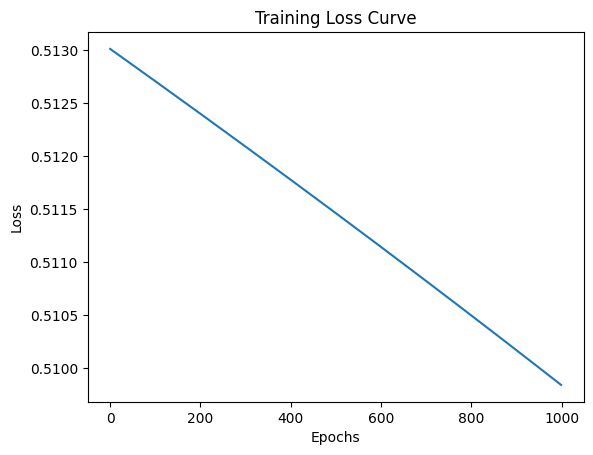

In [28]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [59]:
# Predict on the test set using the custom neural network
_, y_pred_prob = forward(X_test)
y_pred_nn_custom = (y_pred_prob > 0.5).astype(int)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.79      1.00      0.88       314

    accuracy                           0.79       397
   macro avg       0.40      0.50      0.44       397
weighted avg       0.63      0.79      0.70       397



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train.ravel())

y_pred_sklearn = model.predict(X_test)

print(classification_report(y_test, y_pred_sklearn))

              precision    recall  f1-score   support

           0       0.58      0.13      0.22        83
           1       0.81      0.97      0.88       314

    accuracy                           0.80       397
   macro avg       0.69      0.55      0.55       397
weighted avg       0.76      0.80      0.74       397



MEDIUM Sub-step 5: Business Decision

In [32]:
cost_fn = 10   # missing patient (FN)
cost_fp = 1    # false alarm (FP)

In [33]:
thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    preds = (y_pred_prob > t).astype(int)

    TP = np.sum((preds == 1) & (y_test == 1))
    TN = np.sum((preds == 0) & (y_test == 0))
    FP = np.sum((preds == 1) & (y_test == 0))
    FN = np.sum((preds == 0) & (y_test == 1))

    cost = FN * cost_fn + FP * cost_fp

    print(f"Threshold {t:.1f} → Cost: {cost}")

Threshold 0.1 → Cost: 83
Threshold 0.2 → Cost: 83
Threshold 0.3 → Cost: 83
Threshold 0.4 → Cost: 83
Threshold 0.5 → Cost: 83
Threshold 0.6 → Cost: 83
Threshold 0.7 → Cost: 83
Threshold 0.8 → Cost: 2231


HARD Sub-step 6: Why 94% Accuracy is Misleading

In [41]:
# Check class distribution
print(df['readmitted'].value_counts())

readmitted
1    1560
0     421
Name: count, dtype: int64


In [50]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['patient_id', 'readmitted'])
y = df['readmitted']

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y, y_pred))


Accuracy: 0.7874810701665825


In [52]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y, y_pred))

[[  25  396]
 [  25 1535]]


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.06      0.11       421
           1       0.79      0.98      0.88      1560

    accuracy                           0.79      1981
   macro avg       0.65      0.52      0.49      1981
weighted avg       0.73      0.79      0.72      1981



HARD Sub-step 7: Neural Network as Feature Extractor

In [56]:


df_nn_features = df.drop(columns=['patient_id'])

for col in ['smoking_status_never', 'smoking_status_smokes']:
    if col in df_nn_features.columns:
        df_nn_features[col] = df_nn_features[col].astype(int)

X_for_forward = df_nn_features.drop(columns=['readmitted']).values
X_for_forward = (X_for_forward - X_for_forward.mean(axis=0)) / X_for_forward.std(axis=0)


A1, _ = forward(X_for_forward)

# A1 = hidden layer output (embeddings)
X_embed = A1

In [57]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_embed[:split], y_train.ravel())

y_pred_embed = clf.predict(X_embed[split:])

In [60]:
print("Custom Neural Network:")
print(classification_report(y_test, y_pred_nn_custom))

print("Logistic Regression with NN Embeddings:")
print(classification_report(y_test, y_pred_embed))

Custom Neural Network:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.79      1.00      0.88       314

    accuracy                           0.79       397
   macro avg       0.40      0.50      0.44       397
weighted avg       0.63      0.79      0.70       397

Logistic Regression with NN Embeddings:
              precision    recall  f1-score   support

           0       1.00      0.01      0.02        83
           1       0.79      1.00      0.88       314

    accuracy                           0.79       397
   macro avg       0.90      0.51      0.45       397
weighted avg       0.84      0.79      0.70       397



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
